1. 기본 혼동행렬 & 분류 리포트

In [1]:
# 📊 혼동행렬 및 분류 성능 리포트 계산

from sklearn.metrics import confusion_matrix, classification_report

# 실제 정답값 (예: 테스트 데이터의 실제 클래스)
y_true = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0]

# 모델의 예측 결과 (예: KNN 또는 DT가 예측한 결과)
y_pred = [1, 0, 1, 0, 0, 1, 1, 0, 1, 0]

# ✅ 혼동행렬 계산
# 2x2 행렬: [[TN, FP], [FN, TP]]
cm = confusion_matrix(y_true, y_pred)
print("혼동행렬(confusion matrix):")
print(cm)

# ✅ 성능 리포트 출력
# 정밀도(precision), 재현율(recall), F1-score, support(샘플 수) 등 포함
report = classification_report(y_true, y_pred)
print("성능 리포트(classification report):")
print(report)

혼동행렬(confusion matrix):
[[4 1]
 [1 4]]
성능 리포트(classification report):
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10



2. ROC 곡선 & AUC 기본 원리 이해

In [2]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# 예시 데이터: 몸무게(weight), 키(height)
weight = [50, 55, 60, 65, 70, 80, 85, 90, 95, 100]
height = [1.5, 1.6, 1.65, 1.7, 1.75, 1.8, 1.8, 1.85, 1.85, 1.9]

# 실제 클래스: 0은 정상, 1은 고도비만
y_true = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]

# 예측 기준: 몸무게가 threshold 이상이면 '비만(1)'로 예측
threshold = 80
y_pred = []

# 예측값 만들기
for w in weight:
    if w >= threshold:
        y_pred.append(1)
    else:
        y_pred.append(0)

# 혼동행렬 계산
cm = confusion_matrix(y_true, y_pred)
print("혼동행렬:")
print(cm)

# 혼동행렬을 해체하여 요소 추출
TN, FP, FN, TP = cm.ravel()

# ✅ TPR (재현율): 실제 양성 중 예측 맞춘 비율
TPR = TP / (TP + FN)

# ✅ FPR (위양성률): 실제 음성 중 잘못 예측한 비율
FPR = FP / (FP + TN)

print("TPR (재현율):", TPR)
print("FPR (허위 양성률):", FPR)

혼동행렬:
[[5 0]
 [0 5]]
TPR (재현율): 1.0
FPR (허위 양성률): 0.0


3. ROC 곡선 그리기 (임계값 변화에 따른 TPR/FPR 변화 시각화)

Threshold: 55, TPR: 1.00, FPR: 0.80
Threshold: 60, TPR: 1.00, FPR: 0.60
Threshold: 65, TPR: 1.00, FPR: 0.40
Threshold: 70, TPR: 1.00, FPR: 0.20
Threshold: 75, TPR: 1.00, FPR: 0.00
Threshold: 80, TPR: 1.00, FPR: 0.00
Threshold: 85, TPR: 0.80, FPR: 0.00
Threshold: 90, TPR: 0.60, FPR: 0.00
Threshold: 95, TPR: 0.40, FPR: 0.00
Threshold: 100, TPR: 0.20, FPR: 0.00
Threshold: 105, TPR: 0.00, FPR: 0.00


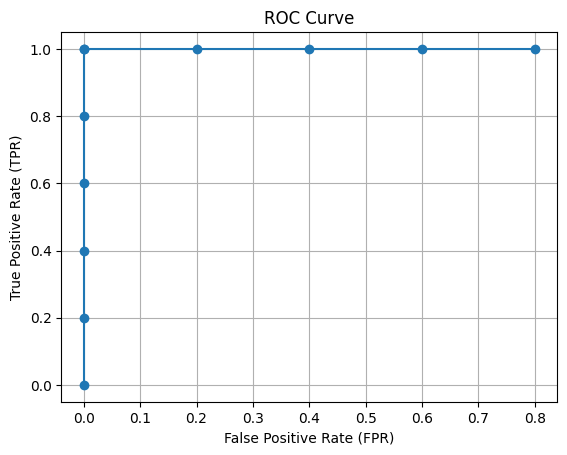

In [3]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# 데이터: 몸무게, 키, 실제 정답
weight = [50, 55, 60, 65, 70, 80, 85, 90, 95, 100]
height = [1.5, 1.6, 1.65, 1.7, 1.75, 1.8, 1.8, 1.85, 1.85, 1.9]
y_true = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]

# ROC 좌표 저장 리스트
fpr_list = []
tpr_list = []

# 다양한 threshold(임계값)를 변경해가며 TPR, FPR 계산
thresholds = np.arange(55, 110, 5)  # 55부터 105까지 5 간격

for threshold in thresholds:
    y_pred = []
    for w in weight:
        y_pred.append(1 if w >= threshold else 0)

    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)

    # 결과 출력
    print(f"Threshold: {threshold}, TPR: {TPR:.2f}, FPR: {FPR:.2f}")

    # 그래프용 리스트에 저장
    fpr_list.append(FPR)
    tpr_list.append(TPR)

# ROC 곡선 시각화
plt.plot(fpr_list, tpr_list, '-o')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.grid()
plt.show()

4. BMI 활용 (개선된 지표, 확장)

In [ ]:
# ✅ BMI = 몸무게 / 키^2 계산
bmi = []
for i in range(len(weight)):
    bmi.append(weight[i] / (height[i] ** 2))

print("BMI:", bmi)

# (시험에서는 ROC 재구성까지는 생략 가능, 개념 확장 정도로 이해)